In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import sparse, linalg
from scipy.io import loadmat,savemat
from math import factorial

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
# from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors

# Seaborn colormap
import seaborn as sns
import colorcet as cc
sns_list = sns.color_palette(cc.glasbey,n_colors=20).as_hex()
sns_list.pop(4)

# sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
cm = sns_cmap

sns_list_balance_models = sns_list.copy()

sns_list_balance_models.insert(0, '#ffffff')  # Insert white at zero position
sns_list_balance_models.pop(1)
sns_cmap_balance_models = ListedColormap(sns_list_balance_models)

cm_balance_models = sns_cmap_balance_models
  
mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']

# Run sPCA on clustered results from final GMM, cluster labels loaded below

In [2]:
load_dir = 'results/GMM_data/grid_spacing_0.05_TF_5/support_x_0.35_support_y_0.35/'

nc = 7# 7 seems to be best # of c.

nfeatures=6
trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + 'features/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + 'features/masked_y_coords_DNS_grid.npy')

# also load features
features = np.load(load_dir + 'features/features.npy')

In [3]:
labels = [r'$T \frac{\partial \Omega_x}{\partial t}$', r'$N \frac{\partial \Omega_x}{\partial n}$',
            r'$\frac{\partial^2 \Omega_x}{\partial t^2}$', r'$\frac{\partial^2 \Omega_x}{\partial n^2}$', 
            #r'$\Omega_x\frac{\partial U}{\partial x}$', r'$\Omega_y\frac{\partial V}{\partial y}$',
            r'$(RS_{\hat{t}})$', r'$(RS_{\hat{n}})$']

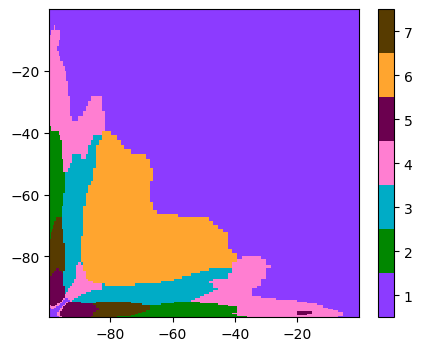

In [4]:
plt.figure(figsize = (5,4))
plt.pcolormesh(masked_x_coords_DNS_grid,masked_y_coords_DNS_grid,cluster_idx.reshape(masked_y_coords_DNS_grid.shape), cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
plt.colorbar(boundaries=np.arange(0.5, nc+1.5), ticks=np.arange(0, nc+1))
# plt.savefig(nc_save_dir + f'ClusterDomain')
plt.show()
plt.close()

In [5]:
def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

In [6]:
features.shape

(7921, 6)

In [7]:
cluster_err = []
alphas = [0.00001,0.0001,0.0005,0.001,0.0025,0.005,0.01,0.0125,0.015,0.0175,0.02,0.0225,0.025,0.0325,0.0375,0.048,0.05,0.0625,0.075,0.0875,0.1,0.11,0.12,0.13,0.14,0.15,0.175,0.2,0.225,0.25,0.3,0.35,0.4,0.45,0.5,0.625,0.75,0.875,1,5,6,7,10,25,50,100]

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i))

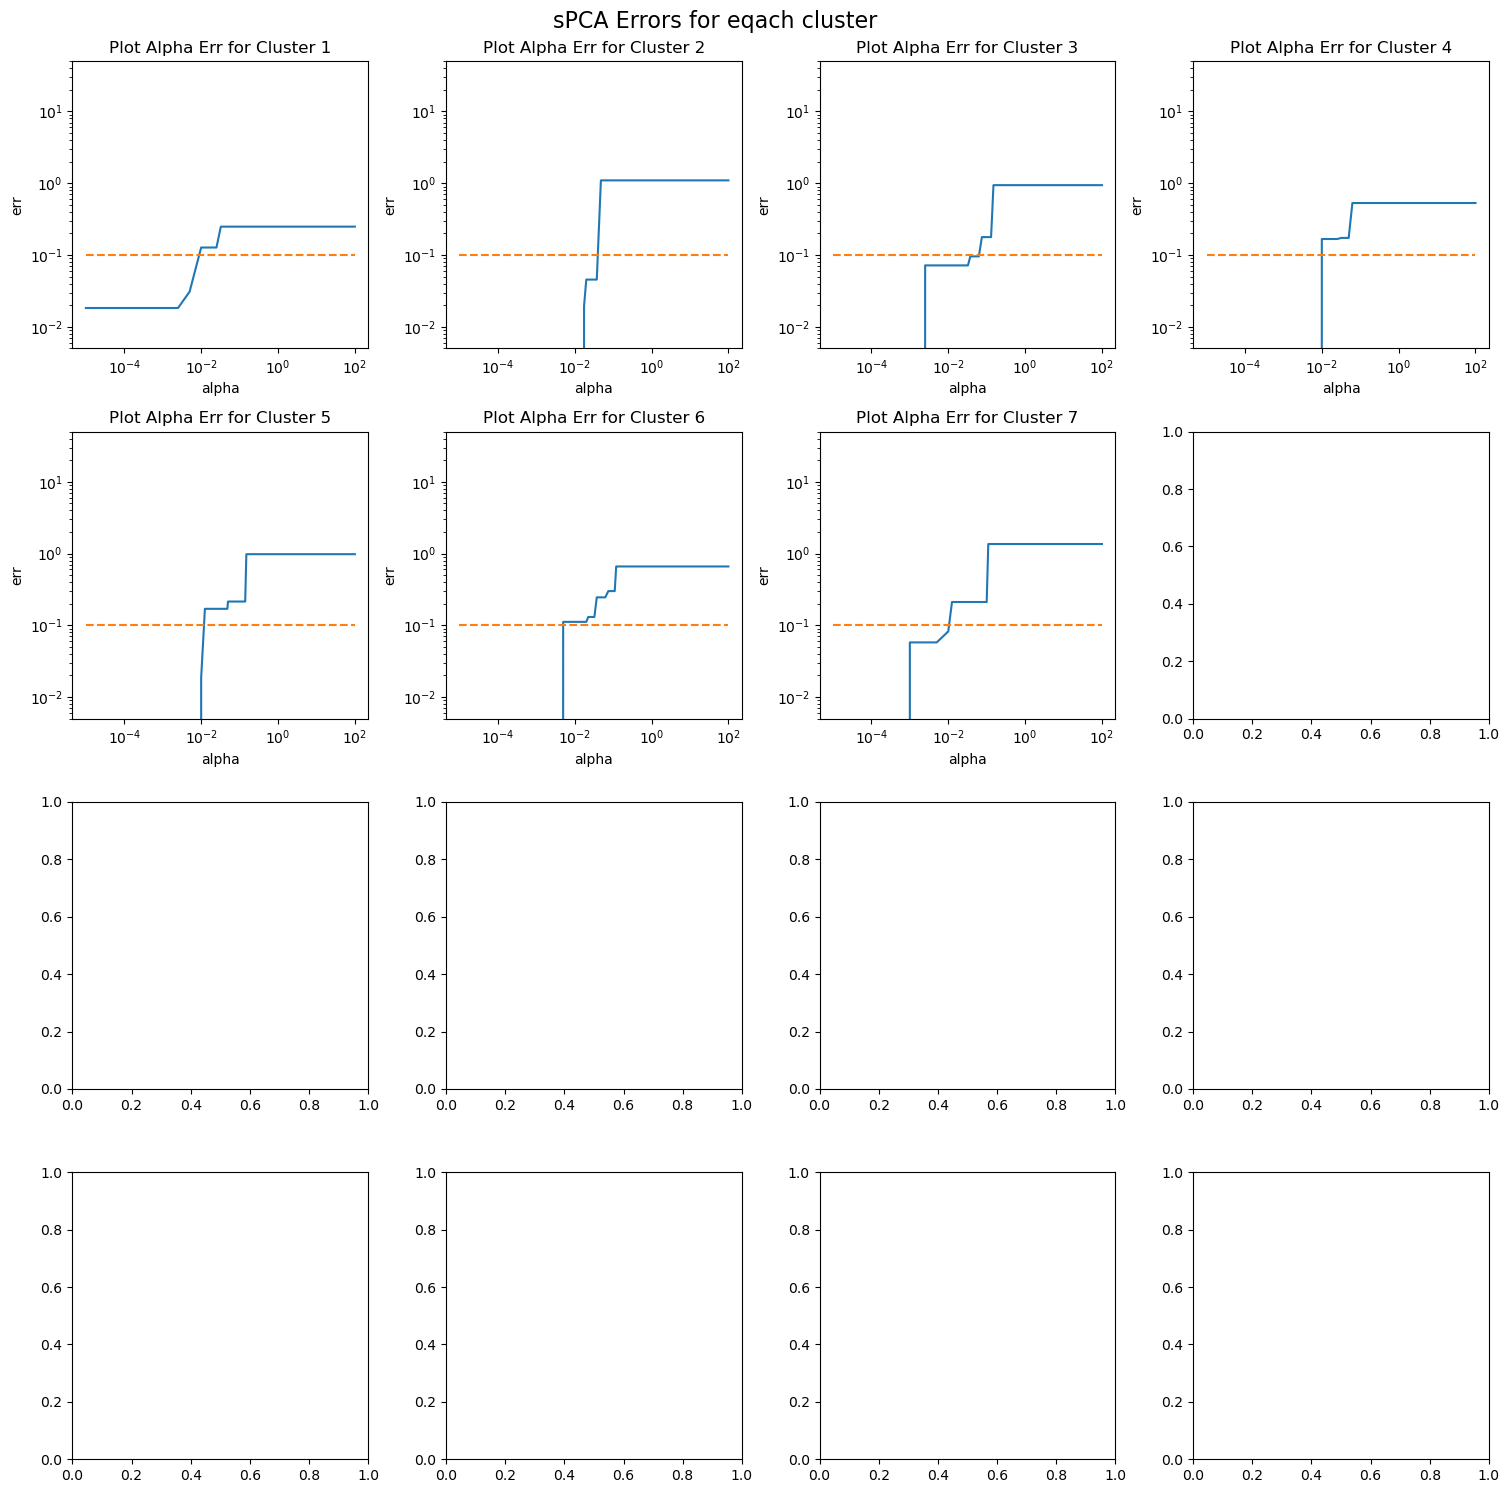

In [8]:
# Create figure and axes with 3x3 subplots, sharing the x-axis
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i in range(nc):
    axes[i].loglog(alphas, cluster_err[i])
    axes[i].set_title(f'Plot Alpha Err for Cluster {i + 1}')
    axes[i].loglog(alphas, 0.1 * np.ones_like(np.array(alphas)), linestyle='--')
    # if i == 2:
    #     axes[i].set_xlim(0.0625,0.0875)
    axes[i].set_xlabel('alpha')
    axes[i].set_ylabel('err')
    axes[i].set_ylim(5e-3,50)

# # Add shared x-label and y-label
# fig.text(0.5, 0.04, 'X Axis', ha='center')
# fig.text(0.04, 0.5, 'Y Axis', va='center', rotation='vertical')

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.suptitle("sPCA Errors for eqach cluster", fontsize=16)
plt.show()

In [9]:
def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
        else: print('None')

    return spca_model

In [10]:
# err_threshold = 28 maximum I can truncate before I loose viscous effect in the part over the the 
err_threshold = 0.3 #0.3

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size - 1:
            alpha_opt.append(alphas[j-1]) # append the last alpha value if there are no alphas that surpass the error level
        else:
            continue

print(alpha_opt)
optimal_alphas = alpha_opt

[50, 0.0375, 0.13, 0.05, 0.14, 0.0625, 0.1]


In [11]:
spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

None


In [12]:
balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

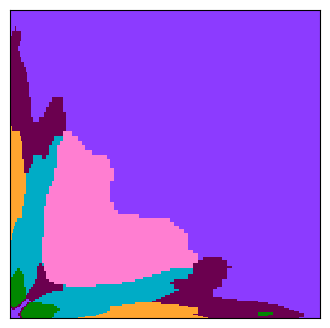

<Figure size 640x480 with 0 Axes>

In [13]:
plt.figure(figsize = (4.0,4.0))
plt.pcolormesh(masked_x_coords_DNS_grid,masked_y_coords_DNS_grid, (balance_idx+1).reshape(masked_y_coords_DNS_grid.shape), cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.savefig(f'VortTran_sPCA_ClusterDomain,nc{nc}', transparent=True,dpi=480)
plt.show()
plt.clf()

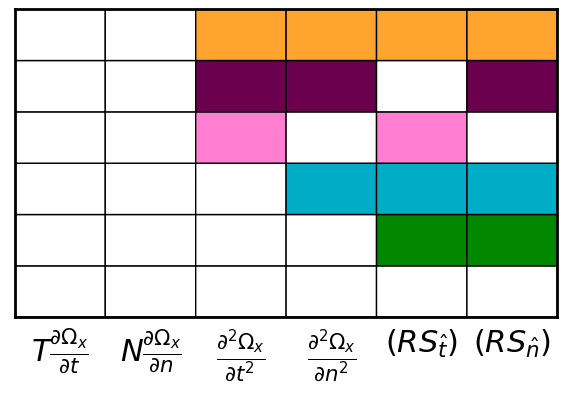

<Figure size 640x480 with 0 Axes>

In [14]:
# Plot a grid with active terms in each cluster
gridmap = balance_models.copy()
gridmask = gridmap==0
gridmap = (gridmap.T*np.arange(nmodels)).T+1  # Scale map so that active terms can be color-coded
gridmap[gridmask] = 0

# NOTE We're skipping the deleting of unidentified terms because I need to count terms correctly identified as 0 in my quantitative metric
# plot spca_model matrix
# Delete zero terms
# grid_mask = np.nonzero( np.all(gridmap==0, axis=0) )[0]
# gridmap = np.delete(gridmap, grid_mask, axis=1)
# grid_labels = np.delete(labels, grid_mask)

grid_labels = labels

plt.figure(figsize=(7, 4))
plt.pcolor(gridmap, vmin=-0.5, vmax=cm.N-0.5, cmap=cm_balance_models, edgecolors='k', linewidth=1)
plt.gca().set_xticks(np.arange(0.5, gridmap.shape[1]+0.5))
plt.gca().set_xticklabels(grid_labels, fontsize=22)
plt.gca().set_yticklabels([])

for axis in ['top','bottom','left','right']:
    plt.gca().spines[axis].set_linewidth(2)

plt.gca().tick_params(axis='both', width=0)
plt.savefig(f'DuctVortTrans_sPCA_Matrix_Model', bbox_inches='tight',transparent=True,dpi=480)
plt.show()
plt.clf()

# save cluster_idx np array and spca_model np
# np.save(save_dir + f'trial{i}/spca_model.npy', balance_models)
# np.save(save_dir + f'trial{i}/cluster_idx.npy', balancemap)

# The decomp is clean, concentrated near where secondary motions actually happen, they don't happen at the centerlines despite affecting them, and is has that region of strong dissipation exactly where it should be .